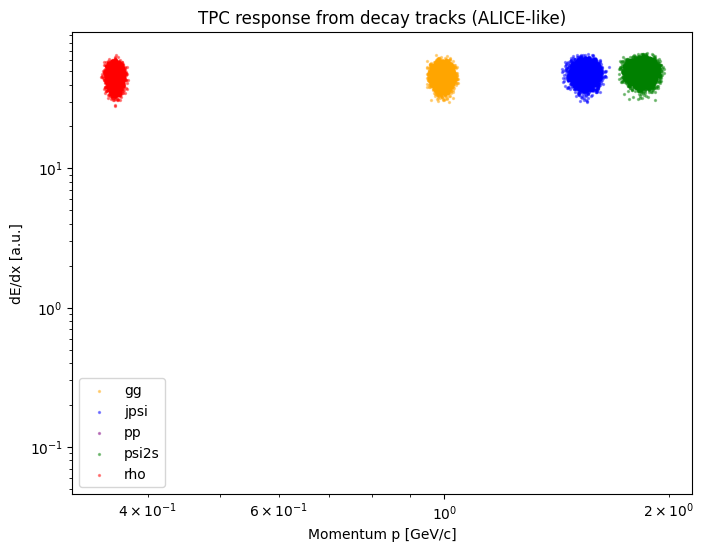

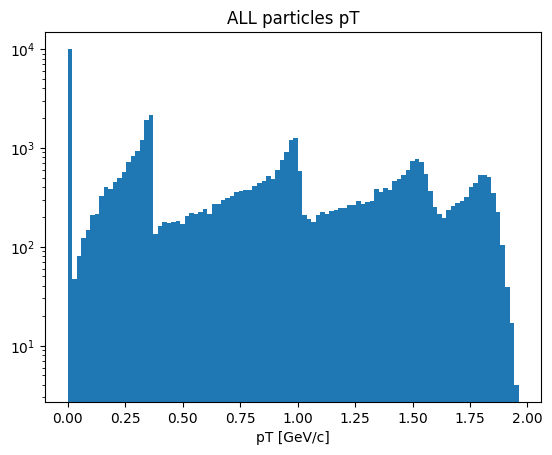

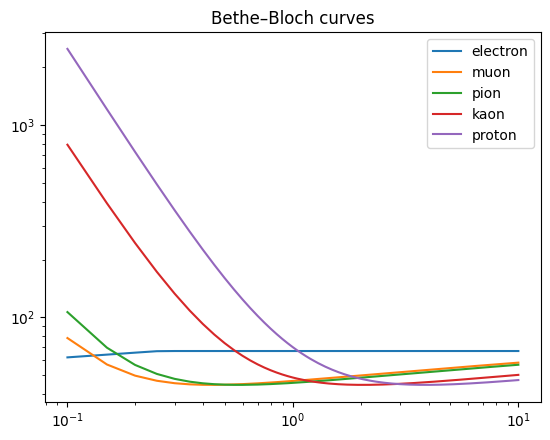

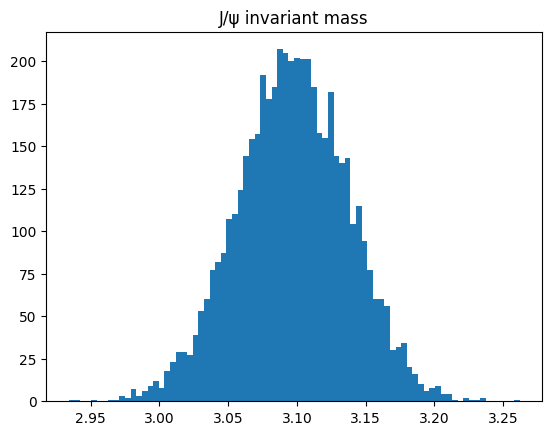

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. BETHE-BLOCH (YOUR VERSION, CLEANED + SAFE)
# ============================================================

def bethe_bloch(momentum, mass, charge=1):
    K = 0.307075
    I = 1.6e-5
    m_e = 0.000511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    beta = np.clip(beta, 1e-6, 0.999999)
    gamma = 1.0 / np.sqrt(1 - beta**2)

    arg = np.clip(
        2 * m_e * beta**2 * gamma**2 / (I**2),
        1e-12, 1e12
    )

    dedx = (K * charge**2 * rho / beta**2) * (0.5 * np.log(arg) - beta**2)
    return np.maximum(dedx * 17, 0.1)

ddef build_tpc_from_events(results):

    mass_map = {
        "rho": 0.13957,
        "jpsi": 0.10566,
        "psi2s": 0.10566,
        "pp": 0.93827,
        "gg": 0.10566
    }

    data = {}

    for decay, res in results.items():

        mass = mass_map[decay]

        p_list = []
        dedx_list = []

        for track in res["tracks"]:

            p = np.linalg.norm(track)

            # keep only physical region (IMPORTANT FIX)
            if p < 0.05 or p > 10:
                continue

            dedx_true = bethe_bloch(p, mass)
            dedx_meas = np.random.normal(dedx_true, 0.08 * dedx_true)

            p_list.append(p)
            dedx_list.append(dedx_meas)

        data[decay] = (np.array(p_list), np.array(dedx_list))

    return data

ddef plot_tpc(data):

    plt.figure(figsize=(8,6))

    colors = {
        "rho": "red",
        "jpsi": "blue",
        "psi2s": "green",
        "pp": "purple",
        "gg": "orange"
    }

    for decay, (p, dedx) in data.items():

        # density plot instead of raw scatter → KEY FIX
        plt.hist2d(
            p,
            dedx,
            bins=120,
            cmap="viridis",
            alpha=0.8
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Momentum p [GeV/c]")
    plt.ylabel("dE/dx [a.u.]")
    plt.title("TPC Bethe–Bloch response (from decay tracks)")
    plt.colorbar(label="counts")
    plt.show()


# ============================================================
# 2. TPC PID RESPONSE (ALICE STYLE)
# ============================================================

def tpc_pid_response(p, particle_type, stretch_factor=1.0):

    mass_dict = {
        "electron": 0.000511,
        "muon": 0.10566,
        "pion": 0.13957,
        "kaon": 0.49367,
        "proton": 0.93827
    }

    m = mass_dict.get(particle_type, 0.13957)

    mean = bethe_bloch(p, m) * stretch_factor
    lower = mean * 0.7
    upper = mean * 1.3

    return mean, lower, upper


def gaussian_tpc_response(p, particle_type, stretch_factor):
    mean, lower, upper = tpc_pid_response(p, particle_type, stretch_factor)
    sigma = (upper - lower) / 6
    return np.random.normal(mean, sigma)


# ============================================================
# 3. ANGLES + MOMENTA (ISOTROPIC DECAY)
# ============================================================

def p_two_body(M, m1, m2):
    term = (M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)
    return np.sqrt(term) / (2*M) if term > 0 else 0


def angles():
    phi = np.random.uniform(0, 2*np.pi)
    costh = np.random.uniform(-1, 1)
    theta = np.arccos(costh)
    return phi, theta


def momentum_vector(p, phi, theta):
    return np.array([
        p*np.sin(theta)*np.cos(phi),
        p*np.sin(theta)*np.sin(phi),
        p*np.cos(theta)
    ])


def decay(M, m1, m2):
    p = p_two_body(M, m1, m2)
    phi, theta = angles()
    p1 = momentum_vector(p, phi, theta)
    p2 = -p1
    return p1, p2


# ============================================================
# 4. MOMENTUM SMEARING (ALICE TPC-LIKE)
# ============================================================

def smear(p):
    p_mag = np.linalg.norm(p)
    sigma = np.sqrt(0.01**2 + (0.01*p_mag)**2)
    p_s = np.random.normal(p_mag, sigma*p_mag)
    return p_s * p / p_mag if p_mag > 0 else p


# ============================================================
# 5. PARTICLE MASSES
# ============================================================

m = {
    "pi": 0.13957,
    "mu": 0.10566,
    "p":  0.93827,
    "rho": 0.77526,
    "jpsi": 3.0969,
    "psi2s": 3.6861
}


# ============================================================
# 6. DECAY MODES
# ============================================================

def rho2pi():
    return decay(m["rho"], m["pi"], m["pi"])

def jpsi2mumu():
    return decay(m["jpsi"], m["mu"], m["mu"])

def psi2s2mumu():
    return decay(m["psi2s"], m["mu"], m["mu"])

def pp():
    return decay(m["p"], m["p"], m["p"])

def gg2ll():
    return decay(2.0, m["mu"], m["mu"])


# ============================================================
# 7. EVENT GENERATOR
# ============================================================

def event_generator(mode, N=10000):

    inv_mass = []
    pt_all = []
    dedx_all = []
    nsig_pi = []
    nsig_p = []
    tracks = []

    for _ in range(N):

        if mode == "rho":
            p1, p2 = rho2pi()
            mass = m["pi"]

        elif mode == "jpsi":
            p1, p2 = jpsi2mumu()
            mass = m["mu"]

        elif mode == "psi2s":
            p1, p2 = psi2s2mumu()
            mass = m["mu"]

        elif mode == "pp":
            p1, p2 = pp()
            mass = m["p"]

        elif mode == "gg":
            p1, p2 = gg2ll()
            mass = m["mu"]

        else:
            raise ValueError("Unknown mode")

        # SMEAR BOTH TRACKS (IMPORTANT)
        p1 = smear(p1)
        p2 = smear(p2)

        tracks += [p1, p2]

        # pT
        pt_all += [
            np.sqrt(p1[0]**2 + p1[1]**2),
            np.sqrt(p2[0]**2 + p2[1]**2)
        ]

        # PID (use p1 only as representative track)
        p_mag = np.linalg.norm(p1)
        dedx = gaussian_tpc_response(p_mag, "pion", 0.4)

        dedx_all.append(dedx)
        nsig_pi.append((dedx - bethe_bloch(p_mag, m["pi"])) / (0.05*dedx))
        nsig_p.append((dedx - bethe_bloch(p_mag, m["p"])) / (0.05*dedx))

        # invariant mass
        E1 = np.sqrt(np.linalg.norm(p1)**2 + mass**2)
        E2 = np.sqrt(np.linalg.norm(p2)**2 + mass**2)

        P4 = np.array([E1 + E2, *(p1 + p2)])
        inv_mass.append(np.sqrt(max(P4[0]**2 - np.linalg.norm(P4[1:])**2, 0)))

    return (
        np.array(inv_mass),
        np.array(pt_all),
        np.array(dedx_all),
        np.array(nsig_pi),
        np.array(nsig_p),
        np.array(tracks)
    )


# ============================================================
# 8. RUN ALL DECAYS
# ============================================================

def run_all(N=5000):

    all_pt = []

    results = {}

    for mode in ["rho", "jpsi", "psi2s", "pp", "gg"]:

        inv, pt, dedx, npi, np_, tr = event_generator(mode, N)

        results[mode] = {
            "inv": inv,
            "pt": pt,
            "dedx": dedx,
            "nsig_pi": npi,
            "nsig_p": np_,
            "tracks": tr
        }

        all_pt.append(pt)

    return results, np.concatenate(all_pt)


# ============================================================
# 9. PLOTS
# ============================================================

def plot_pt(pt):
    plt.figure()
    plt.hist(pt, bins=100)
    plt.yscale("log")
    plt.title("ALL particles pT")
    plt.xlabel("pT [GeV/c]")
    plt.show()


def plot_bb():

    p = np.linspace(0.1, 10, 200)

    for name in ["electron", "muon", "pion", "kaon", "proton"]:
        m_map = {
            "electron": 0.000511,
            "muon": 0.10566,
            "pion": 0.13957,
            "kaon": 0.49367,
            "proton": 0.93827
        }

        plt.plot(p, bethe_bloch(p, m_map[name]), label=name)

    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title("Bethe–Bloch curves")
    plt.show()


# ============================================================
# 10. EXECUTION
# ============================================================

results, all_pt = run_all(5000)


p, dedx, labels = build_tpc_from_events(results)

plot_tpc_from_events(p, dedx, labels)

plot_pt(all_pt)
plot_bb()


plt.hist(results["jpsi"]["inv"], bins=80)
plt.title("J/ψ invariant mass")
plt.show()
